# GEA units: from LD blocks to k-mer-covered units (decision notebook)

The GEA test/estimation unit, end to end:

1. **Blocks** = HapFM partition (CompleteLDPartition corr=0.2 + BigLD) on the all-class
   231-founder panel, **CLQcut r²=0.9**, **panel-support filter call-rate≥0.9** → 58,376 fine
   blocks (median 7 variants).
2. **Problem:** median-7-variant blocks are too thin to be k-mer-covered — only ~38% get a
   local h fit at 10× (benchmark below). AF accuracy stays flat because untrackable blocks
   fall back to global h (recombination is rare in selfing pools) — but we want **local h**
   where we can, as insurance against real (selection-driven) recombination.
3. **Fix:** grow blocks to be k-mer-covered, **LD-guided** (relax r² only where too thin,
   merging along the LD gradient), to ≥500 panel k-mers (≈2.5 kb). HapFM untouched.
4. **Final unit map:** `final_units_dynld_K500.tsv` — 20,051 units, used as BOTH the kMate
   h-estimation window and the selection unit (covered → local h, desert → global fallback).

In [1]:
import numpy as np, pandas as pd, glob
import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({"figure.dpi":110,"font.size":11,"axes.grid":True,"grid.alpha":.3})
BR = "/global/scratch/users/tbellg/kmate/analysis/grenenet_gea/blocks_mcf90" 

## 1. Coarseness benchmark — trackability ↑, accuracy flat

window-mode kMate on block maps of increasing coarseness (base + variant-floor 8/15/25/40),
6 sim seeds (p231, Chr1, recombinant). %local-fit climbs 38→92%, but **R² is flat (~0.988)** —
local h adds no accuracy over global fallback here, because recombination is rare. (So merging
is for *coverage/insurance*, not accuracy.)

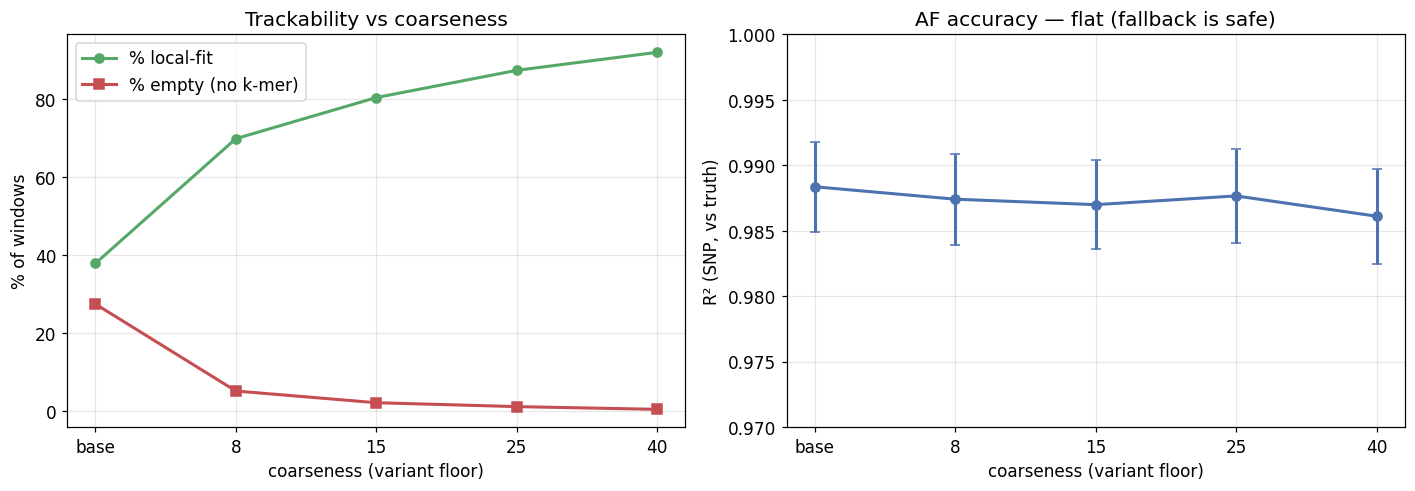

In [2]:
S = pd.read_csv("/global/scratch/users/tbellg/kmate/benchmarks/ldblock_window_test/coarse_sweep_scores.csv")
order=["base","8","15","25","40"]
g=S.groupby("level")
fig,ax=plt.subplots(1,2,figsize=(13,4.6))
x=range(len(order))
ax[0].plot(x,[g.get_group(l).pct_local.mean() for l in order],"o-",color="#55A868",lw=2,label="% local-fit")
ax[0].plot(x,[g.get_group(l).pct_empty.mean() for l in order],"s-",color="#C44E52",lw=2,label="% empty (no k-mer)")
ax[0].set_xticks(list(x)); ax[0].set_xticklabels(order); ax[0].set_xlabel("coarseness (variant floor)")
ax[0].set_ylabel("% of windows"); ax[0].set_title("Trackability vs coarseness"); ax[0].legend()
ax[1].errorbar(x,[g.get_group(l).r2_snp.mean() for l in order],yerr=[g.get_group(l).r2_snp.std() for l in order],
               fmt="o-",color="#4C72B0",lw=2,capsize=3)
ax[1].set_xticks(list(x)); ax[1].set_xticklabels(order); ax[1].set_ylim(0.97,1.0)
ax[1].set_xlabel("coarseness (variant floor)"); ax[1].set_ylabel("R² (SNP, vs truth)")
ax[1].set_title("AF accuracy — flat (fallback is safe)")
plt.tight_layout(); plt.show()

## 2. The k-mer coverage threshold

Per-block PANEL k-mers vs the local-fit rate (Chr1). A block needs **≈500 panel k-mers
(≈30 variants / ≈2 kb)** to reliably (98%) estimate h locally at 10×. ~28% of blocks have
**zero** panel k-mers — true deserts (centromeric/repetitive), unfixable by any size.

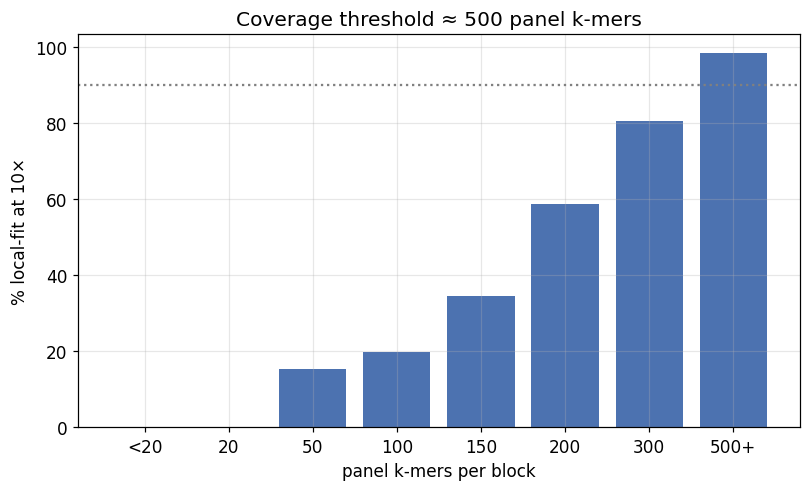

In [3]:
C = pd.read_csv(f"{BR}/chr1_block_kmer_coverage.csv")
bins=[0,20,50,100,150,200,300,500,1e9]; lab=["<20","20","50","100","150","200","300","500+"]
C["b"]=pd.cut(C.panel_kmers,bins,right=False)
pl=C.groupby("b",observed=True).status.apply(lambda s:(s==0).mean()*100)
fig,ax=plt.subplots(figsize=(7.5,4.6))
ax.bar(range(len(pl)),pl.values,color="#4C72B0")
ax.axhline(90,ls=":",color="grey"); ax.set_xticks(range(len(lab))); ax.set_xticklabels(lab)
ax.set_xlabel("panel k-mers per block"); ax.set_ylabel("% local-fit at 10×")
ax.set_title("Coverage threshold ≈ 500 panel k-mers"); plt.tight_layout(); plt.show()

## 3. Fine-block size distributions (CLQ0.9) — why merge the thin tail

84% of blocks are <30 variants but hold only ~34% of variants. Loosening r² doesn't reach
the threshold (CLQ0.5 still median 10 var) and would coarsen the good blocks too — so we
**merge the thin tail**, not loosen r².

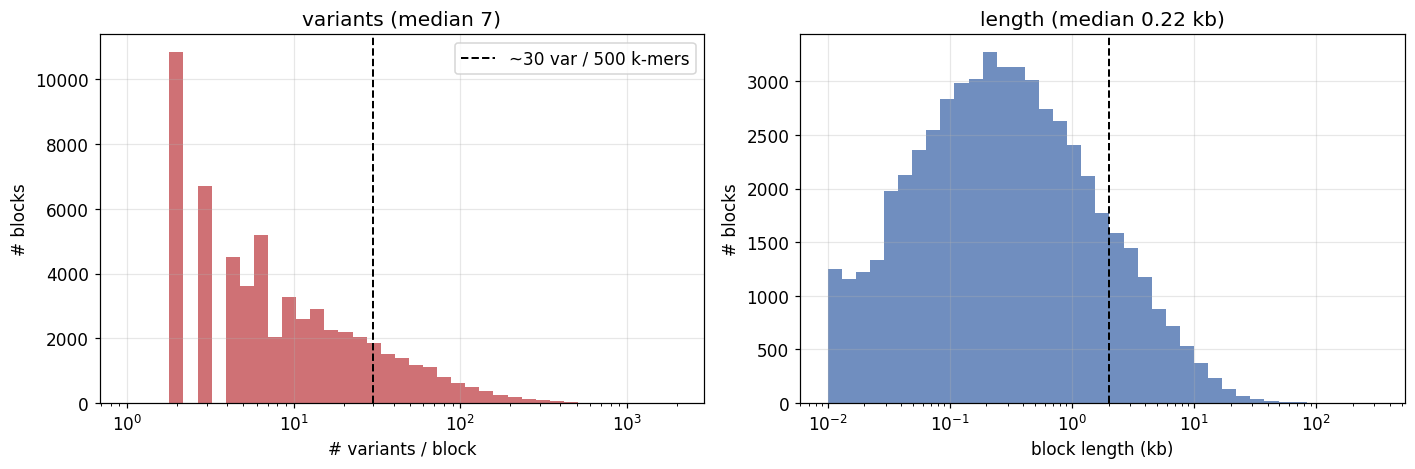

In [4]:
B = pd.concat([pd.read_csv(f,sep="\t") for f in sorted(glob.glob(f"{BR}/chr*_clq0.9_blocks_clq0.9.tsv"))],ignore_index=True)
B["kb"]=(B.end_pos-B.start_pos)/1000
fig,ax=plt.subplots(1,2,figsize=(13,4.4))
ax[0].hist(B.n_variants,bins=np.logspace(0,3.3,40),color="#C44E52",alpha=.8); ax[0].set_xscale("log")
ax[0].axvline(30,ls="--",color="k",lw=1.3,label="~30 var / 500 k-mers"); ax[0].legend()
ax[0].set_xlabel("# variants / block"); ax[0].set_ylabel("# blocks"); ax[0].set_title(f"variants (median {int(B.n_variants.median())})")
ax[1].hist(B.kb,bins=np.logspace(-2,2.5,40),color="#4C72B0",alpha=.8); ax[1].set_xscale("log")
ax[1].axvline(2,ls="--",color="k",lw=1.3); ax[1].set_xlabel("block length (kb)"); ax[1].set_ylabel("# blocks")
ax[1].set_title(f"length (median {B.kb.median():.2f} kb)")
plt.tight_layout(); plt.show()

## 4. Final dynamic-LD units — the 4 distributions

`final_units_dynld_K500.tsv` (20,051 units). Covered (≥500 k-mers, 69%) = local-fit
independent units; desert (31%) = global fallback. Note within-unit LD (r²~0.31) and PC1-VE
(~0.48) are LOWER than the fine blocks — that's the expected cost of merging for coverage,
and it's fine: the unit's *state* is the founder/haplotype frequency vector **h** (which
resolves the multiple haplotypes), not a single PC1 trajectory.

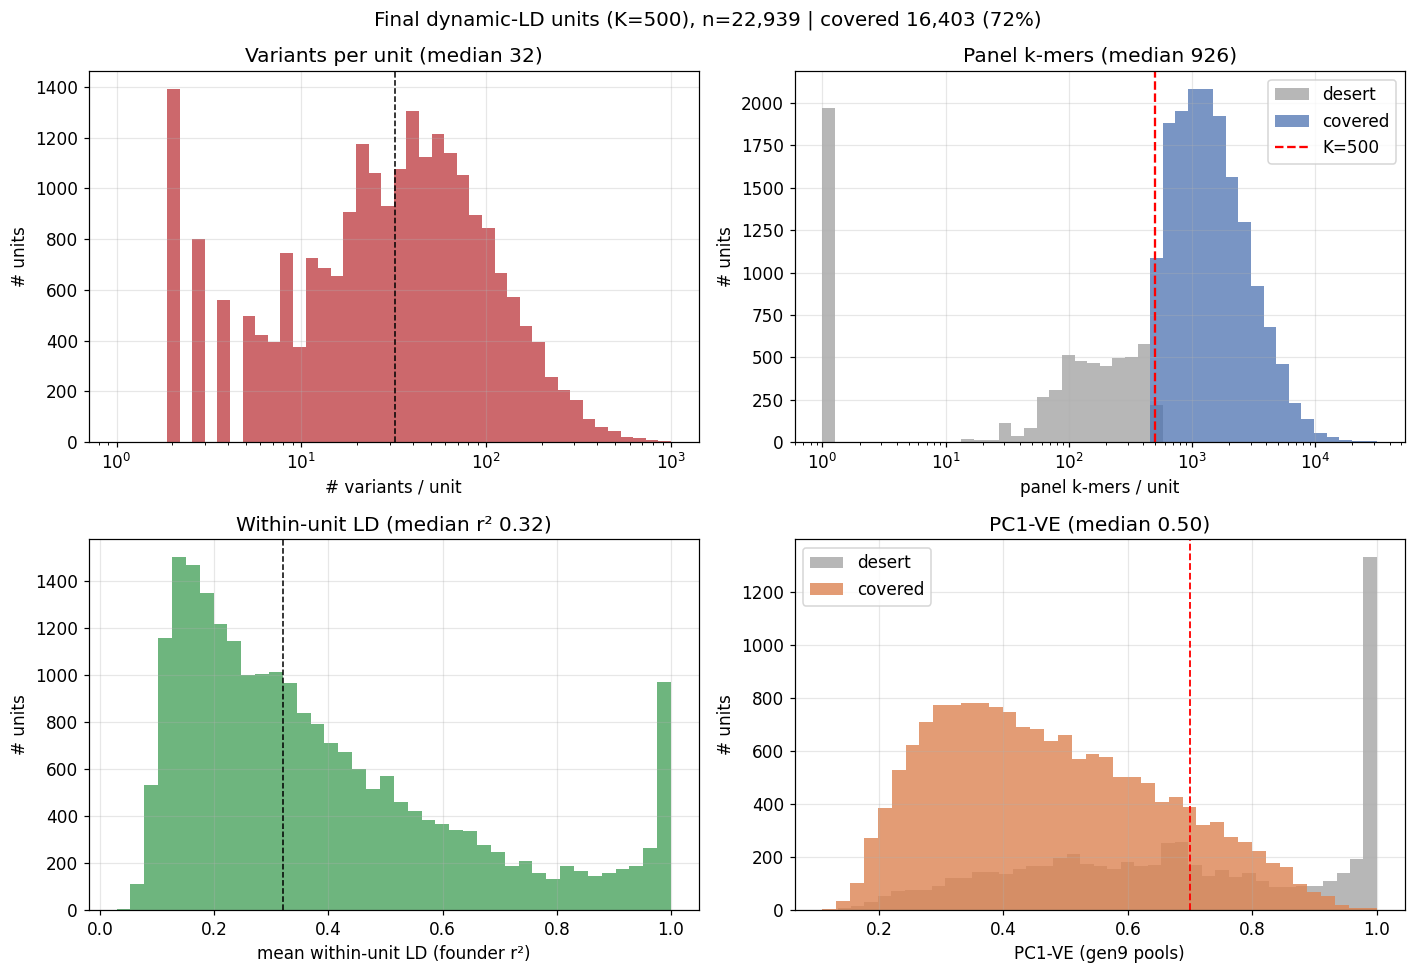

In [5]:
D = pd.read_csv(f"{BR}/final_units_dynld_K500_metrics.csv")
cov=D[D.covered]; des=D[~D.covered]
fig,ax=plt.subplots(2,2,figsize=(13,9))
ax[0,0].hist(D.n_variants,bins=np.logspace(0,3,45),color="#C44E52",alpha=.85); ax[0,0].set_xscale("log")
ax[0,0].axvline(D.n_variants.median(),ls="--",color="k",lw=1); ax[0,0].set_xlabel("# variants / unit"); ax[0,0].set_ylabel("# units")
ax[0,0].set_title(f"Variants per unit (median {int(D.n_variants.median())})")
b2=np.logspace(0,4.5,45)
ax[0,1].hist(des.panel_kmers.clip(lower=1),bins=b2,color="#999999",alpha=.7,label="desert")
ax[0,1].hist(cov.panel_kmers,bins=b2,color="#4C72B0",alpha=.75,label="covered"); ax[0,1].set_xscale("log")
ax[0,1].axvline(500,ls="--",color="red",lw=1.5,label="K=500"); ax[0,1].legend()
ax[0,1].set_xlabel("panel k-mers / unit"); ax[0,1].set_ylabel("# units"); ax[0,1].set_title(f"Panel k-mers (median {int(D.panel_kmers.median())})")
ax[1,0].hist(D.mean_r2.dropna(),bins=40,color="#55A868",alpha=.85); ax[1,0].axvline(D.mean_r2.median(),ls="--",color="k",lw=1)
ax[1,0].set_xlabel("mean within-unit LD (founder r²)"); ax[1,0].set_ylabel("# units"); ax[1,0].set_title(f"Within-unit LD (median r² {D.mean_r2.median():.2f})")
ax[1,1].hist(des.pc1_ve.dropna(),bins=40,color="#999999",alpha=.7,label="desert")
ax[1,1].hist(cov.pc1_ve.dropna(),bins=40,color="#DD8452",alpha=.8,label="covered"); ax[1,1].axvline(0.7,ls="--",color="red",lw=1.2)
ax[1,1].set_xlabel("PC1-VE (gen9 pools)"); ax[1,1].set_ylabel("# units"); ax[1,1].set_title(f"PC1-VE (median {D.pc1_ve.median():.2f})"); ax[1,1].legend()
plt.suptitle(f"Final dynamic-LD units (K=500), n={len(D):,} | covered {int(D.covered.sum()):,} ({100*D.covered.mean():.0f}%)",fontsize=13)
plt.tight_layout(); plt.show()